In [1]:
# First Of All We Import The Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Analysis

In [2]:
data = pd.read_csv('cardata.csv')                   # import data
data.head(10).style.background_gradient(cmap='Blues')             # Color the background in a gradient style

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.350000,5.590000,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.750000,9.540000,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.250000,9.850000,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.850000,4.150000,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.600000,6.870000,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.250000,9.830000,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.750000,8.120000,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.500000,8.610000,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.750000,8.890000,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.450000,8.920000,42367,Diesel,Dealer,Manual,0


In [3]:
df = pd.DataFrame(data)                      # Convert to dataframe
Age = [max(df['Year'] +1) - i for i in df['Year']]                   # make 'Age' column and add to dataframe
df.insert(0 , 'Age' , Age)
df.describe()

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,5.372093,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,2.891554,5.082812,8.644115,38886.883882,0.247915
min,1.000000,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,3.000000,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,5.000000,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,7.000000,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,16.000000,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [4]:
#  با توجه به اینکه تعداد سمپل ها در تمام ستون ها یکسان است میتوان نتیجه گرفت که دیتاست شامل میسینگ ولیو نیست 
# در ادامه بررسی های بیشتری نیز انجام میشود 

In [5]:
data.columns

Index(['Age', 'Car_Name', 'Year', 'Selling_Price', 'Present_Price',
       'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [6]:
df2 = pd.DataFrame(data , columns=['Car_Name' , 'Fuel_Type', 'Seller_Type', 'Transmission'])
df2.describe()             # make new dataframe from string features for describe them

,Car_Name,Fuel_Type,Seller_Type,Transmission
count,301,301,301,301
unique,98,3,2,2
top,city,Petrol,Dealer,Manual
freq,26,239,195,261


In [7]:
df.shape

(301, 10)

In [8]:
df.info()                  #Information from dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            301 non-null    int64  
 1   Car_Name       301 non-null    object 
 2   Year           301 non-null    int64  
 3   Selling_Price  301 non-null    float64
 4   Present_Price  301 non-null    float64
 5   Kms_Driven     301 non-null    int64  
 6   Fuel_Type      301 non-null    object 
 7   Seller_Type    301 non-null    object 
 8   Transmission   301 non-null    object 
 9   Owner          301 non-null    int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 23.6+ KB


In [9]:
df.drop('Car_Name' , axis=1 , inplace=True)             #drop 'Car_Name' feature

In [10]:
df['Owner'].value_counts()              # count of the unique value for 'Owner'

0    290
1     10
3      1
Name: Owner, dtype: int64

In [11]:
df['Transmission'].value_counts()             # count of the unique value for 'Transmission'

Manual       261
Automatic     40
Name: Transmission, dtype: int64

In [12]:
df['Seller_Type'].value_counts()                    # count of the unique value for 'Seller_Type'

Dealer        195
Individual    106
Name: Seller_Type, dtype: int64

In [13]:
df['Fuel_Type'].value_counts()                       # count of the unique value for 'Fuel_Type'

Petrol    239
Diesel     60
CNG         2
Name: Fuel_Type, dtype: int64

In [14]:
data1 = dict(df.groupby('Year')['Selling_Price'].mean())     # make group 'Selling_Price' by 'Year' and earn mean of each group
K=2                                 
data = dict()                            
for key in data1:                           # round values of dictionary
    data[key] = round(data1[key], K)
data

{2003: 1.3,
 2004: 1.5,
 2005: 2.49,
 2006: 1.44,
 2007: 0.16,
 2008: 1.0,
 2009: 2.82,
 2010: 5.26,
 2011: 2.38,
 2012: 3.84,
 2013: 3.54,
 2014: 4.76,
 2015: 5.93,
 2016: 5.21,
 2017: 6.21,
 2018: 9.25}

In [15]:
data_items = data.items()
data_list = list(data_items)

df1 = pd.DataFrame(data_list , columns=['Year' , 'Mean Of Selling Per Year'])         #conver dictionary to dataframe
df1

,Year,Mean Of Selling Per Year
0,2003,1.30
1,2004,1.50
2,2005,2.49
3,2006,1.44
4,2007,0.16
5,2008,1.00
6,2009,2.82
7,2010,5.26
8,2011,2.38
9,2012,3.84


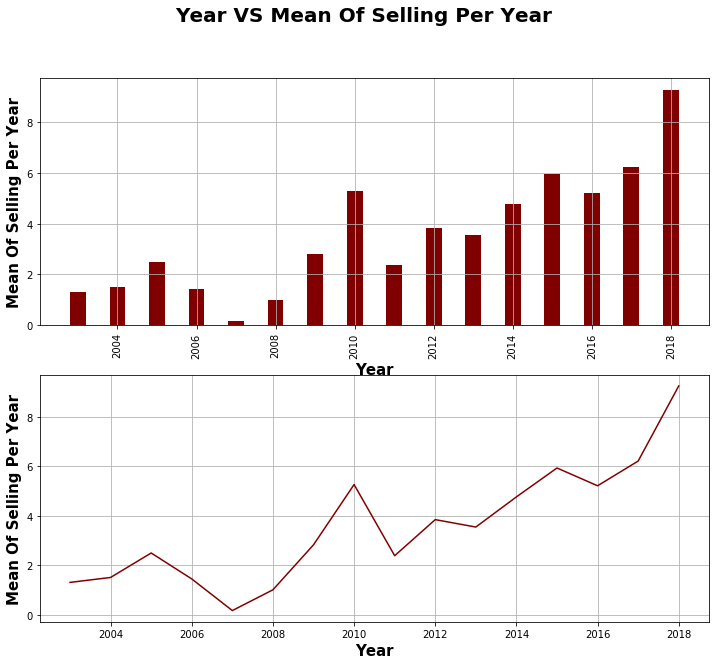

In [16]:
# plot data of new dataframe 
# first with barplot
plt.figure(figsize=(12 , 10))
plt.subplot(2 , 1 , 1)
plt.bar(df1['Year'] , df1['Mean Of Selling Per Year'] , color='maroon' , width=0.4)      # with bar
plt.xlabel('Year' , fontsize=15 , fontweight ='bold')              #xlabel
plt.xticks(rotation=90)              # add xticks
plt.ylabel('Mean Of Selling Per Year' , fontsize=15 , fontweight ='bold')             # ylabel
plt.grid()                 # Tabulation chart

# and then with plot
plt.subplot(2 , 1 , 2)
plt.plot(df1['Year'] , df1['Mean Of Selling Per Year'] , color='maroon')               # with plot
plt.xlabel('Year' , fontweight ='bold' , fontsize=15)                #xlabel
plt.ylabel('Mean Of Selling Per Year', fontweight ='bold' , fontsize=15)            #ylabel
plt.grid()              # Tabulation chart

plt.suptitle('Year VS Mean Of Selling Per Year', fontsize=20 , fontweight ='bold')
plt.show()

In [17]:
# همانطور که در نمودار مشخص است با گذشت سال ها میانگین فروش خودرو در هر سال افزایش میابد
# که نشان دهنده افزایش تقاضا نسبت به گذشته است

In [18]:
data1 = dict(df.groupby('Year')['Present_Price'].mean())     # make group 'Present_Price' by 'Year' and earn mean of each group
K=2
data = dict()
for key in data1:                                 # round values of dictionary
    data[key] = round(data1[key], K)
data

{2003: 5.13,
 2004: 12.35,
 2005: 9.49,
 2006: 9.06,
 2007: 0.66,
 2008: 4.76,
 2009: 10.6,
 2010: 14.33,
 2011: 5.15,
 2012: 7.98,
 2013: 6.82,
 2014: 7.84,
 2015: 8.18,
 2016: 6.55,
 2017: 7.01,
 2018: 9.83}

In [19]:
data_items = data.items()
data_list = list(data_items)

df2 = pd.DataFrame(data_list , columns=['Year' , 'Mean Of Present Price Per Year'])      #conver dictionary to dataframe
df2

,Year,Mean Of Present Price Per Year
0,2003,5.13
1,2004,12.35
2,2005,9.49
3,2006,9.06
4,2007,0.66
5,2008,4.76
6,2009,10.60
7,2010,14.33
8,2011,5.15
9,2012,7.98


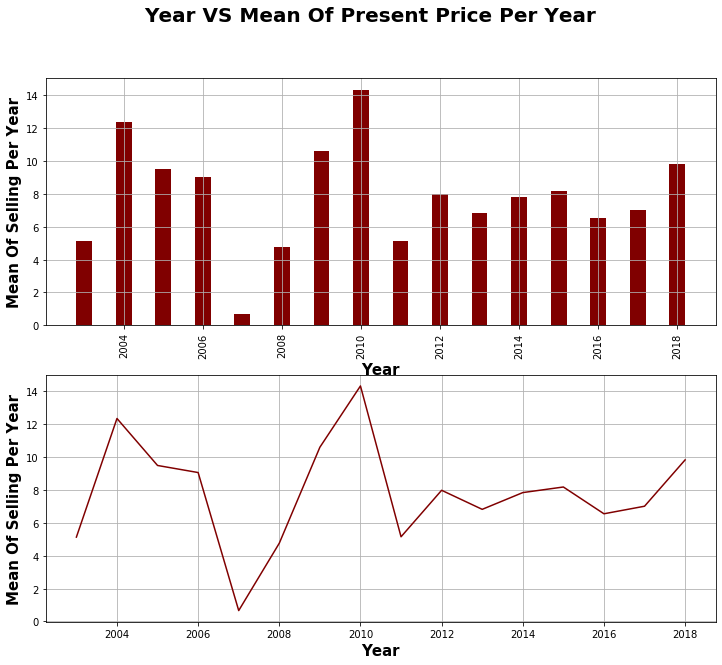

In [20]:
# plot data of new dataframe 
# first with barplot
plt.figure(figsize=(12 , 10))
plt.subplot(2 , 1 , 1)
plt.bar(df2['Year'] , df2['Mean Of Present Price Per Year'] , color='maroon' , width=0.4)         #with bar 
plt.xlabel('Year' , fontsize=15 , fontweight ='bold')              #xlabel
plt.xticks(rotation=90)                   # add xticks
plt.ylabel('Mean Of Selling Per Year' , fontsize=15 , fontweight ='bold')                       #ylabel
plt.grid()                  # Tabulation chart

# and then with plot
plt.subplot(2 , 1 , 2)
plt.plot(df2['Year'] , df2['Mean Of Present Price Per Year'] , color='maroon')               # with scatterplot
plt.xlabel('Year' , fontweight ='bold' , fontsize=15)                #xlabel
plt.ylabel('Mean Of Selling Per Year', fontweight ='bold' , fontsize=15)            #ylabel
plt.grid()              # Tabulation chart

plt.suptitle('Year VS Mean Of Present Price Per Year', fontsize=20 , fontweight ='bold')
plt.show()

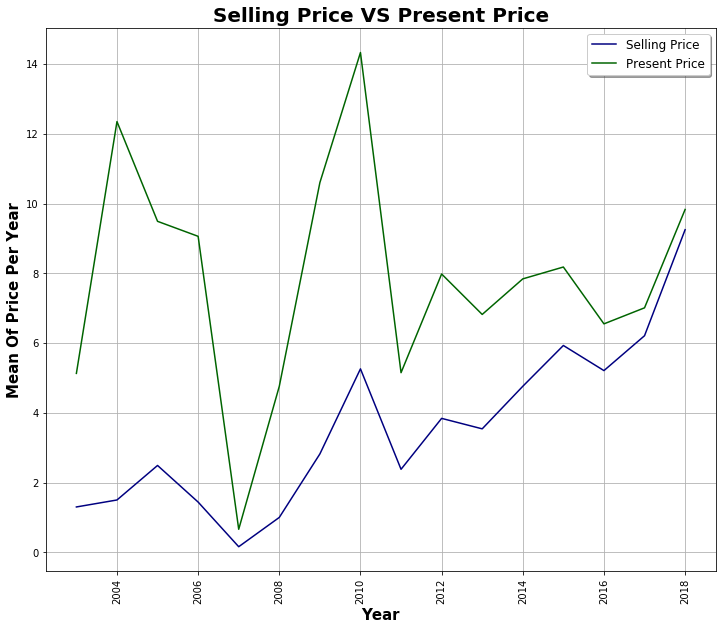

In [21]:
# Compare selling price with present price with plot

plt.figure(figsize=(12 , 10))
plt.plot(df1['Year'] , df1['Mean Of Selling Per Year'] , color='navy', label='Selling Price')
plt.plot(df2['Year'] , df2['Mean Of Present Price Per Year'] , color='darkgreen' , label='Present Price')
plt.xlabel('Year' , fontsize=15 , fontweight ='bold')
plt.xticks(rotation=90)
plt.ylabel('Mean Of Price Per Year' , fontsize=15 , fontweight ='bold')
plt.title('Selling Price VS Present Price' , fontsize=20 , fontweight ='bold')
plt.grid()
plt.legend(loc='best' , fontsize=12 , shadow=True)
plt.show()

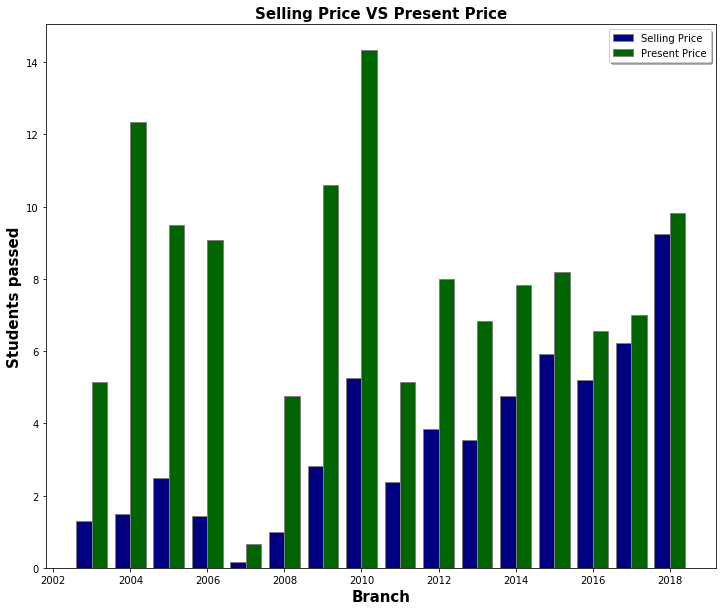

In [22]:
# Compare selling price with present price with barplot

fig , ax = plt.subplots(figsize =(12, 10))

# Make the plot
ax.bar(df1['Year'] - 0.2 , df1['Mean Of Selling Per Year'],color ='navy',
        edgecolor ='grey', label ='Selling Price' , width = 0.40)
ax.bar(df2['Year'] + 0.2 , df2['Mean Of Present Price Per Year'] , color ='darkgreen',
        edgecolor ='grey', label ='Present Price' , width = 0.40)
 

plt.xlabel('Branch', fontweight ='bold', fontsize = 15)
plt.ylabel('Students passed', fontweight ='bold', fontsize = 15)
plt.title('Selling Price VS Present Price' , fontweight ='bold', fontsize = 15)

plt.legend(shadow=True)
plt.show()

In [23]:
# همانطور که در نمودار های مقایسه ای بالا مشخص است قیمت قبلی خودروی خریداری شده مشخصا بیشتر از قیمت فعلی آن است و درعین حال
# نمودار ها نشان از وابستگی زیاد این دو فیچر به یکدیگر دارند

Average selling price for CNG is : 3.1
Average selling price for Diesel is : 10.28
Average selling price for Petrol is : 3.26




Average Present price for CNG is : 6.42
Average Present price for Diesel is : 15.81
Average Present price for Petrol is : 5.58


Plot The Data :


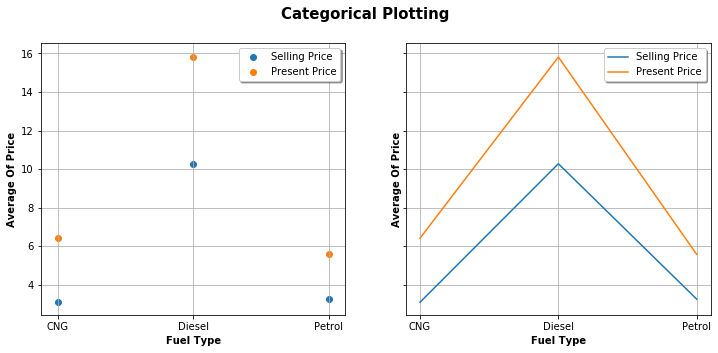

In [24]:
# in this kernel we first make group 'Selling Price' and 'Present Price' based on fuel type
# and then compare them with plot

data1 = dict(df.groupby('Fuel_Type')['Selling_Price'].mean())            # make group 'Selling Price' based on fuel type
K=2
data = dict()
for key in data1:
    data[key] = round(data1[key], K)
for fuel , price in data.items():                                # round values of dictionary
    print('Average selling price for' , fuel , 'is :' , price)

print('\n')
print('==================================================================')
print('\n')

data2 = dict(df.groupby('Fuel_Type')['Present_Price'].mean())          # make group 'Selling Price' based on fuel type
K=2
data3 = dict()
for key in data2:
    data3[key] = round(data2[key], K)
for fuel , price in data3.items():                           # round values of dictionary
    print('Average Present price for' , fuel , 'is :' , price)

print('\n')    
print('Plot The Data :')                # now plot data with scatterplot and plot
names = list(data.keys())
values = list(data.values())

name = list(data3.keys())
value = list(data3.values())

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axs[0].scatter(names, values , label='Selling Price')
axs[0].scatter(name, value , label='Present Price')
axs[0].set_xlabel('Fuel Type' , fontsize=10 , fontweight ='bold')
axs[0].set_ylabel('Average Of Price' , fontsize=10 , fontweight ='bold')
axs[0].grid()
axs[0].legend(loc='best' , shadow=True)

axs[1].plot(names, values , label='Selling Price')
axs[1].plot(name, value , label ='Present Price')
axs[1].set_xlabel('Fuel Type', fontsize=10 , fontweight ='bold')
axs[1].set_ylabel('Average Of Price' , fontsize=10 , fontweight ='bold')
axs[1].grid()
axs[1].legend(loc='best' , shadow=True)

fig.suptitle('Categorical Plotting' , fontsize=15 , fontweight ='bold')
plt.show()

In [25]:
# همانطور که مشخص است میانگین قیمت خودرو برای خودروهایی که از سوخت دیزل استفاده میکنند نسبت به سوخت بنزین و گاز بیشتر است

Average selling price for Dealer is : 6.72
Average selling price for Individual is : 0.87




Average Present price for Dealer is : 10.89
Average Present price for Individual is : 1.64


Plot The Data :


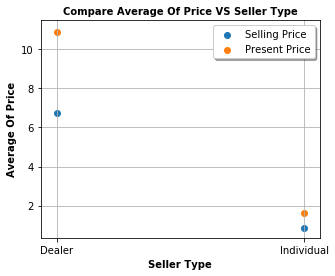

In [26]:
# in this kernel we first make group 'Selling Price' and 'Present Price' based on seller type
# and then compare them with plot

data1 = dict(df.groupby('Seller_Type')['Selling_Price'].mean())      # make group 'Selling Price' based on seller type
K=2
data = dict()
for key in data1:                           # round values of dictionary
    data[key] = round(data1[key], K)
for Seller , price in data.items():
    print('Average selling price for' , Seller , 'is :' , price)

print('\n')
print('==================================================================')
print('\n')

data2 = dict(df.groupby('Seller_Type')['Present_Price'].mean())    # make group 'Selling Price' based on seller type
K=2
data3 = dict()
for key in data2:                  # round values of dictionary
    data3[key] = round(data2[key], K)
for Seller , price in data3.items():
    print('Average Present price for' , Seller , 'is :' , price)

print('\n')    
print('Plot The Data :')                      # now plot data with scatterplot and plot
names = list(data.keys())
values = list(data.values())

name = list(data3.keys())
value = list(data3.values())

plt.figure(figsize=(5 , 4))
plt.scatter(names, values , label='Selling Price')
plt.scatter(name, value , label='Present Price')
plt.xlabel('Seller Type' , fontsize=10 , fontweight ='bold')
plt.ylabel('Average Of Price' , fontsize=10 , fontweight ='bold')
plt.title('Compare Average Of Price VS Seller Type' , fontsize=10 , fontweight ='bold')
plt.grid()
plt.legend(loc='best' , shadow=True)
plt.show()    

In [27]:
# متوسط قیمت خودروی فروخته شده در معامله های بدون واسطه و دلال بسیار پایین تر است

Average selling price for Automatic is : 9.42
Average selling price for Manual is : 3.93




Average Present price for Automatic is : 15.32
Average Present price for Manual is : 6.45


Plot The Data :


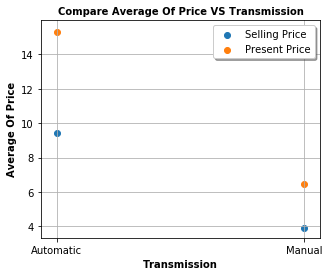

In [28]:
# in this kernel we first make group 'Selling Price' and 'Present Price' based on Transmission
# and then compare them with plot

data1 = dict(df.groupby('Transmission')['Selling_Price'].mean())    # make group 'Selling Price' based on seller type
K=2
data = dict()
for key in data1:                        # round values of dictionary
    data[key] = round(data1[key], K)
for Transmission , price in data.items():
    print('Average selling price for' , Transmission , 'is :' , price)

print('\n')
print('==================================================================')
print('\n')

data2 = dict(df.groupby('Transmission')['Present_Price'].mean())       # make group 'Selling Price' based on seller type
K=2
data3 = dict()
for key in data2:                         # round values of dictionary
    data3[key] = round(data2[key], K)
for Transmission , price in data3.items():
    print('Average Present price for' , Transmission , 'is :' , price)
    
print('\n')    
print('Plot The Data :')                  # now plot data with scatterplot and plot
names = list(data.keys())
values = list(data.values())

name = list(data3.keys())
value = list(data3.values())

plt.figure(figsize=(5 , 4))
plt.scatter(names, values , label='Selling Price')
plt.scatter(name, value , label='Present Price')
plt.xlabel('Transmission' , fontsize=10 , fontweight ='bold')
plt.ylabel('Average Of Price' , fontsize=10 , fontweight ='bold')
plt.title('Compare Average Of Price VS Transmission' , fontsize=10 , fontweight ='bold')
plt.grid()
plt.legend(loc='best' , shadow=True)
plt.show()       

In [29]:
# متوسط قیمت خودروی اتوماتیک بالاتر از خودروی دستی است

## Plot Data For Detection Noises And Outliers

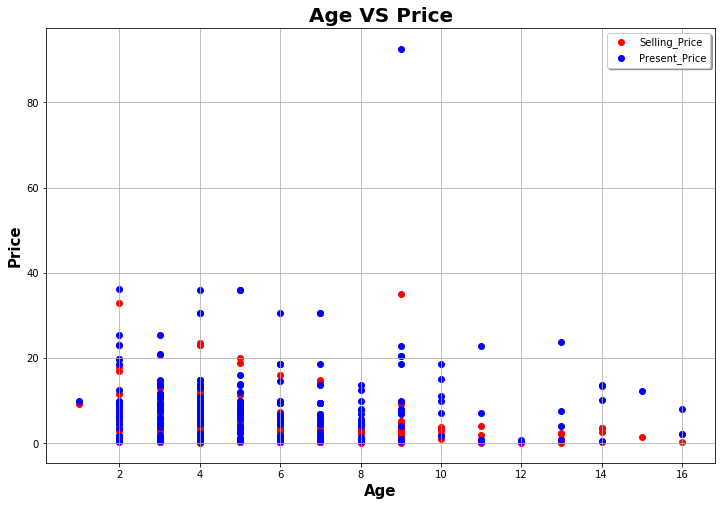

In [30]:
# plot data , compare 'Age' VS 'Price'
plt.figure(figsize=(12 , 8))
plt.scatter(df['Age'] , df['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df['Age'] , df['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Age' , fontweight ='bold' , fontsize=15)    
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)               
plt.title('Age VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

In [31]:
# افزایش سن و کارکرد خودرو قیمت آن را کاهش میدهد

### Detection Noises :
### in df['Present_Price'] > 80

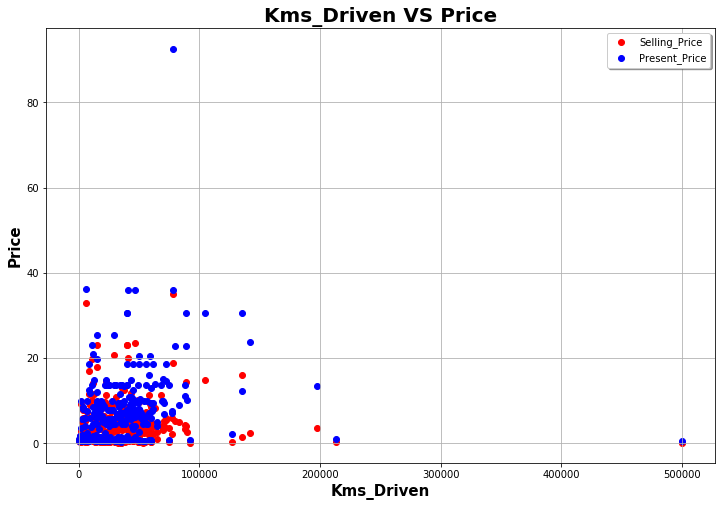

In [32]:
# plot data , compare 'Kms_Driven' VS 'Price'
plt.figure(figsize=(12 , 8))
plt.scatter(df['Kms_Driven'] , df['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df['Kms_Driven'] , df['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Kms_Driven' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Kms_Driven VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

In [33]:
# تجمع بیشتر داده ها در بازه قیمتی بین ۰ تا ۲۰ و بازه حرکتی بین ۰ تا ۱۰۰هزار است

### Detection Noises :
### in df['Present_Price'] > 80
### & df['Kms_Driven'] > 400000

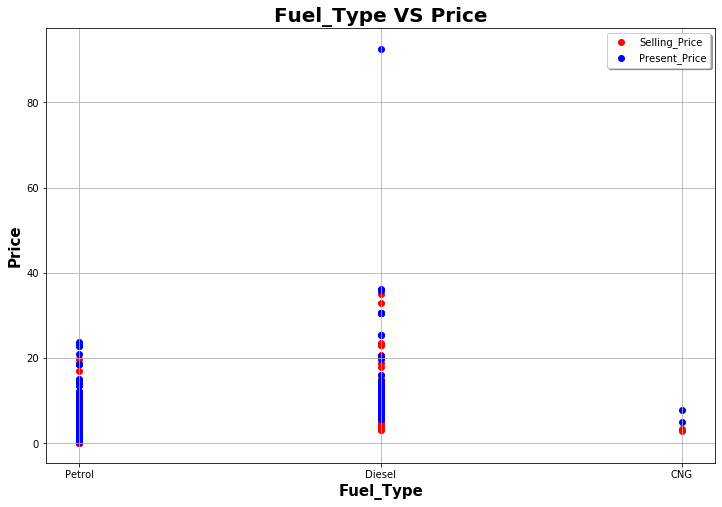

In [34]:
# plot data , compare 'Fuel_Type' VS 'Price'
plt.figure(figsize=(12 , 8))
plt.scatter(df['Fuel_Type'] , df['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df['Fuel_Type'] , df['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Fuel_Type' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Fuel_Type VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

In [35]:
# همانطور که در این نمودار هم مشخص است میانگین قیمت برای خودروهای استفاده کننده از سوخت دیزل بیشتر از دو نوع سوخت دیگر است

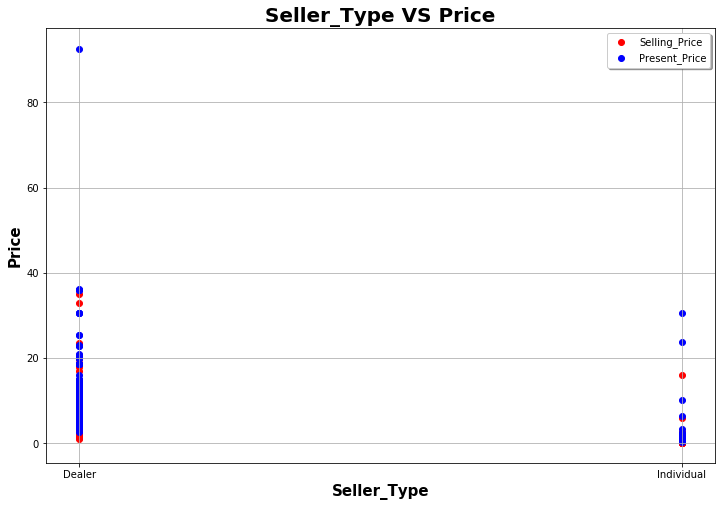

In [36]:
# plot data , compare 'Seller_Type' VS 'Price'
plt.figure(figsize=(12 , 8))
plt.scatter(df['Seller_Type'] , df['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df['Seller_Type'] , df['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Seller_Type' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Seller_Type VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

In [37]:
# همانطور که قبلا هم بررسی شد و در اینجا نیز مشخص است میانگین قیمت برای خودروهایی که باواسطه معامله میشوند بیشتر است

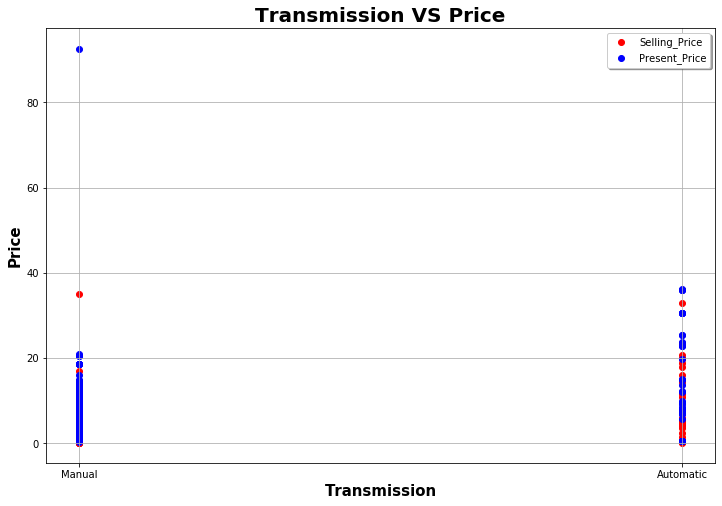

In [38]:
# plot data , compare 'Transmission' VS 'Price'
plt.figure(figsize=(12 , 8))
plt.scatter(df['Transmission'] , df['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df['Transmission'] , df['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Transmission' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Transmission VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

In [39]:
# همانطور که قبلا هم بررسی شد و در اینجا نیز مشخص است میانگین قیمت برای خودروهای اتوماتیک نسبت به خودروهای دستی بیشتر است

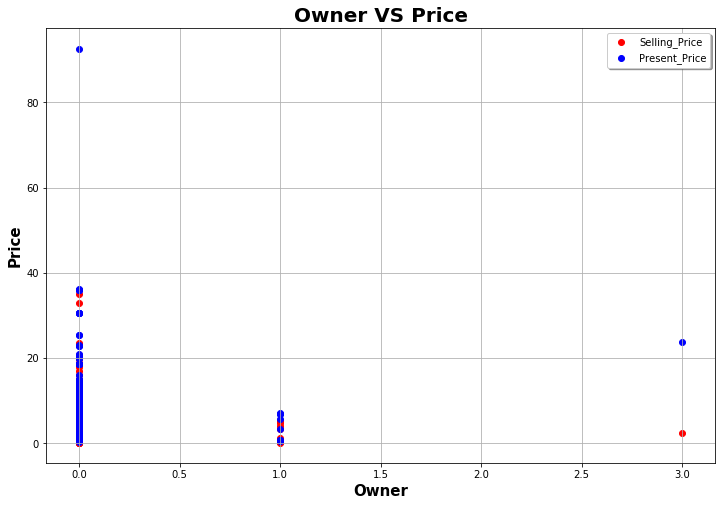

In [40]:
# plot data , compare 'Owner' VS 'Price'
plt.figure(figsize=(12 , 8))
plt.scatter(df['Owner'] , df['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df['Owner'] , df['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Owner' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Owner VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

In [41]:
# متوسط قیمت برای خودروهایی که از قبل مالک نداشتند بیشتر است و همچنین تعداد زیادی از دیتاهای دیتاست خودروهایی هستند که از قبل مالک نداشتند

## Detection And Drop Missing Values

In [42]:
print("Show the missing values of DataFrame: \n\n", df.isnull().sum())      # Show the missing values of DataFrame

Show the missing values of DataFrame: 

 Age              0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [43]:
# همانطور که قبلا نیز بررسی کردیم داده گمشده ای در دیتاست وجود ندارد

## Drop noises

In [44]:
df[df['Present_Price'] > 80]

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
86,9,2010,35.0,92.6,78000,Diesel,Dealer,Manual,0


In [45]:
# این سمپل به دلیل قیمت سابق فروخته شده بیشتری که نسبت به سایر سمپل ها دارد داده مشکوک به نویز محسوب میشود
# با بررسی بقیه ویژگی های این دیتا به عنوان مثال نوع معامله باواسطه و نوع سوخت دیزل و نداشتن مالک قبلی 
#و همچنین قیمت فروش ماکزیممی که نسبت به سایر دیتاها دارد میتوان احتمال داد که داده نویز نمی باشد
#اما راجع به نویز بودن یا نبودن آن نمی توان اظهارنظر قطعی کرد

In [46]:
df[df['Kms_Driven'] > 400000] 

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
196,11,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0


In [47]:
# این داده نیز کیلومتری که طی کرده است عدد بسیار بزرگتری از سایر دیتاها دارد این خودرو ۱۱ سال کارکرد دارد
# در ادامه سعی کرده ایم این دیتا و کیلومتری که طی کرده است را با دیتاهایی که بیشترین کارکرد و سن را داشته اند مقایسه کنیم  

In [48]:
df[df['Age'] == 16]

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
37,16,2003,0.35,2.28,127000,Petrol,Individual,Manual,0
39,16,2003,2.25,7.98,62000,Petrol,Dealer,Manual,0


In [49]:
# همانطور که معلوم است خودروهایی با ۱۶ سال کارکرد کیلومتری که طی کرده اند چیزی کمتر از یک پنجم دیتای ۱۹۶ است
# اما باز هم در مورد نویز بودن یا نبودن دیتا نمیتوان اظهار نظر قطعی کرد

In [50]:
# با توجه به اینکه این امکان وجود دارد که این سمپل به دلیل میزان اهمیت زیادی که دارد در دیتاست گنجانده شده باشد
# و صاحب دیتا بخواهد تاثیر این سمپل بر مدل را بداند 
# و همچنین با توجه به دیتای کمی که دیتاست دارد و ناهماهنگی در توزیعی که این دیتا ایجاد کرده است
# حذف کردن یا نکردن آن نیاز به اطلاعات بیشتری دارد

In [51]:
df_new = df[df['Present_Price'] < 80] 
df_new = df_new[df_new['Kms_Driven'] < 400000]
df_new = df_new.reset_index(drop=True)
df_new

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,6,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,8,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,5,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
294,3,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
295,4,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
296,10,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
297,2,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [52]:
# در اینجا ما سعی کردیم دیتافریم جدیدی ایجاد کرده که در آن داده های مشکوک حذف شده است 
#اما در مدلسازی دیتافریم اصلی را قرار میدهیم 

## Reprocessing

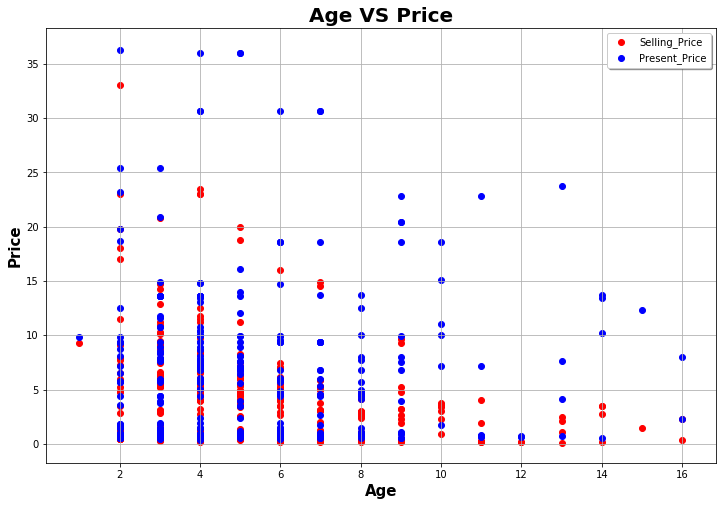

In [53]:
# plot data , compare 'Age' VS 'Price' after processing
plt.figure(figsize=(12 , 8))
plt.scatter(df_new['Age'] , df_new['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df_new['Age'] , df_new['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Age' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Age VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

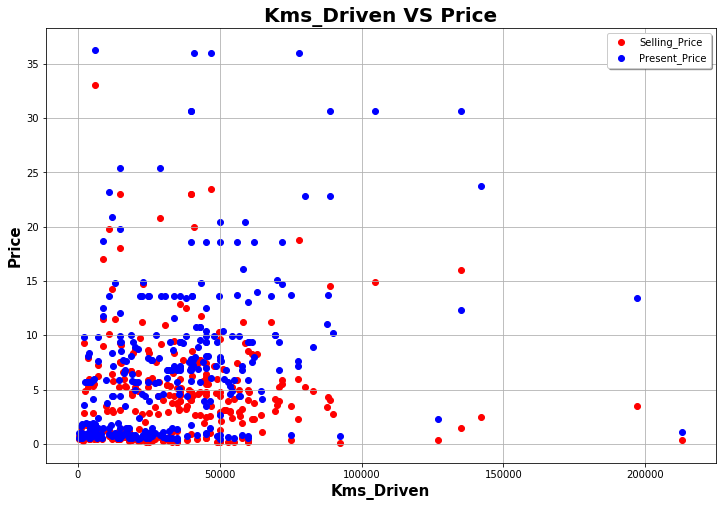

In [54]:
# plot data , compare 'Kms_Driven' VS 'Price' after processing
plt.figure(figsize=(12 , 8))
plt.scatter(df_new['Kms_Driven'] , df_new['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df_new['Kms_Driven'] , df_new['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Kms_Driven' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Kms_Driven VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

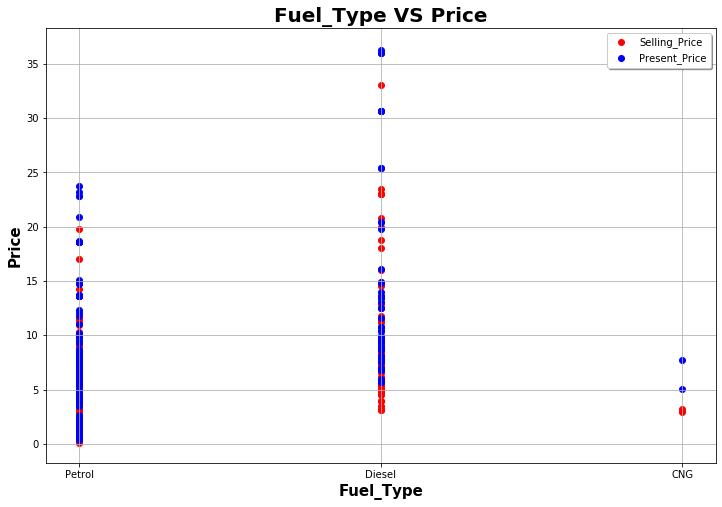

In [55]:
# plot data , compare 'Fuel_Type' VS 'Price' after processing
plt.figure(figsize=(12 , 8))
plt.scatter(df_new['Fuel_Type'] , df_new['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df_new['Fuel_Type'] , df_new['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Fuel_Type' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Fuel_Type VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

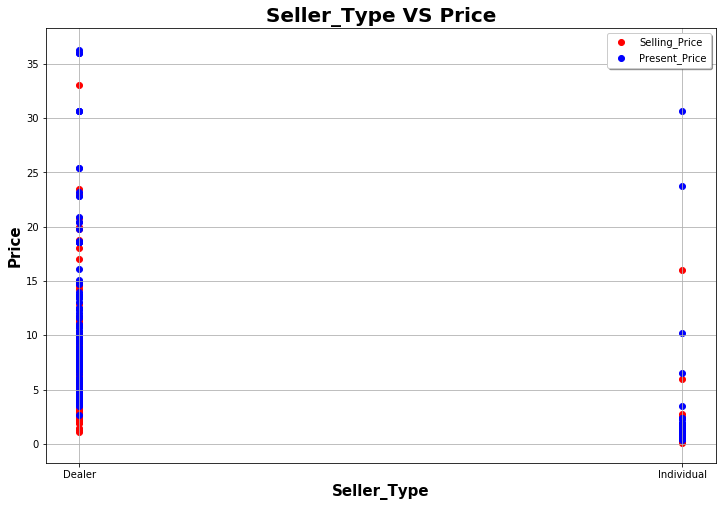

In [56]:
# plot data , compare 'Seller_Type' VS 'Price' after processing
plt.figure(figsize=(12 , 8))
plt.scatter(df_new['Seller_Type'] , df_new['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df_new['Seller_Type'] , df_new['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Seller_Type' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Seller_Type VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

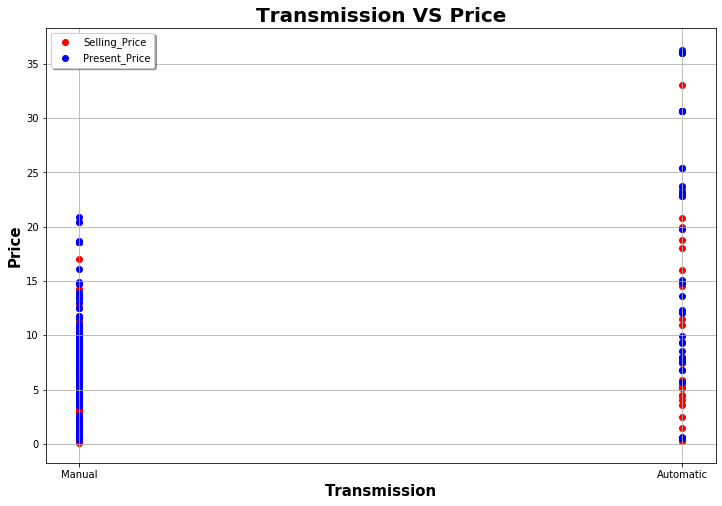

In [57]:
# plot data , compare 'Transmission' VS 'Price' after processing
plt.figure(figsize=(12 , 8))
plt.scatter(df_new['Transmission'] , df_new['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df_new['Transmission'] , df_new['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Transmission' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Transmission VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

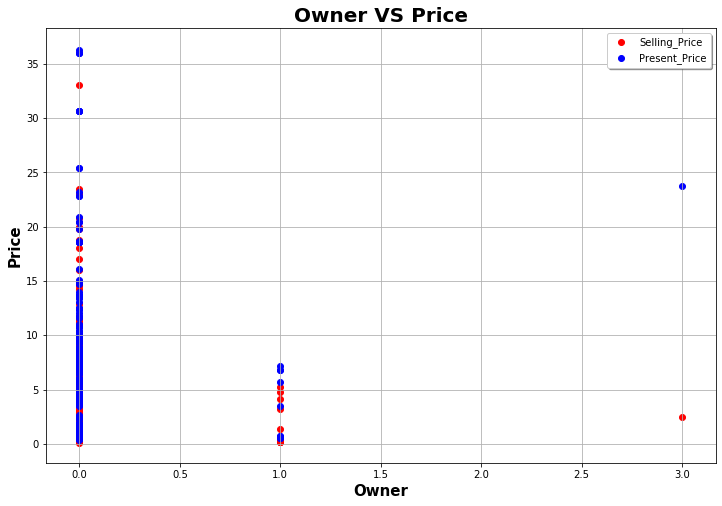

In [58]:
# plot data , compare 'Owner' VS 'Price' after processing
plt.figure(figsize=(12 , 8))
plt.scatter(df_new['Owner'] , df_new['Selling_Price'] , color='r' , label='Selling_Price')
plt.scatter(df_new['Owner'] , df_new['Present_Price'] , color='b' , label='Present_Price')
plt.xlabel('Owner' , fontweight ='bold' , fontsize=15)
plt.ylabel('Price' , fontweight ='bold' , fontsize=15)
plt.title('Owner VS Price' , fontweight ='bold' , fontsize=20)
plt.legend(loc='best' , shadow=True)
plt.grid()
plt.show()

# Regression Model Of Machine Learning

In [59]:
# First of all we import the libraries
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [60]:
# بعد از وارد کردن کتابخانه ها می توان ستون های با دسته بندی رشته ای را به عدد تبدیل کرد 
#  تا قابل استفاده در مدلسازی باشند با دو روش اینکار را می توان انجام داد
#  1- روش دستی 
#  2- استفاده از کتابخانه ها

## Use the ' LabelEncoder ' library

In [61]:
from sklearn.preprocessing import LabelEncoder      # Encode target labels with value between 0 and n_classes-1

le = LabelEncoder()
le.fit(df['Fuel_Type'].drop_duplicates())
df['Fuel_Type'] = le.transform(df['Fuel_Type'])

le.fit(df['Seller_Type'].drop_duplicates())
df['Seller_Type'] = le.transform(df['Seller_Type'])

le.fit(df['Transmission'].drop_duplicates())
df['Transmission'] = le.transform(df['Transmission'])

## Use manual method

In [62]:
## x = df['Fuel_Type'].unique()
## x

In [63]:
## y = range(len(x))
## for i , j in zip(x , y):
##     df.replace(i , j , inplace=True)
## df

In [64]:
## x = df['Seller_Type'].unique()
## x

In [65]:
## y = range(len(x))
## for i , j in zip(x , y):
##     df.replace(i , j , inplace=True)
## df

In [66]:
## x = df['Transmission'].unique()
## x

In [67]:
## y = range(len(x))
## for i , j in zip(x , y):
##     df.replace(i , j , inplace=True)
## df

## Normalize data

In [68]:
# Preprocessing از کتابخانه  MinMaxScaler سپس دیتا را نرمال سازی میکنیم با استفاده از دستور  

In [69]:
Scaler = preprocessing.MinMaxScaler(feature_range=(0 , 1))   #  Transform features by scaling each feature to a given range
norm = Scaler.fit_transform(df)
norm_df = pd.DataFrame(norm , columns=['Age' , 'Year' , 'Selling_Price' , 'Present_Price',  
                                       'Kms_Driven',
                                       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'])
norm_df

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.733333,0.093123,0.057109,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.666667,0.133238,0.099913,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.933333,0.204871,0.103273,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.533333,0.078797,0.041504,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.733333,0.128940,0.070980,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
296,0.133333,0.866667,0.269341,0.122237,0.067043,0.5,0.0,1.0,0.0
297,0.200000,0.800000,0.111748,0.060468,0.119119,1.0,0.0,1.0,0.0
298,0.600000,0.400000,0.093123,0.115735,0.175043,1.0,0.0,1.0,0.0
299,0.066667,0.933333,0.326648,0.131990,0.017017,0.5,0.0,1.0,0.0


In [70]:
X = pd.DataFrame(norm_df , columns=['Age' , 'Year' , 'Present_Price' ,
                                    'Kms_Driven',
                                    'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'])     # Selecting Features
y = norm_df['Selling_Price'].values.reshape(-1 , 1)
X

,Age,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.733333,0.057109,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.666667,0.099913,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.933333,0.103273,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.533333,0.041504,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.733333,0.070980,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
296,0.133333,0.866667,0.122237,0.067043,0.5,0.0,1.0,0.0
297,0.200000,0.800000,0.060468,0.119119,1.0,0.0,1.0,0.0
298,0.600000,0.400000,0.115735,0.175043,1.0,0.0,1.0,0.0
299,0.066667,0.933333,0.131990,0.017017,0.5,0.0,1.0,0.0


In [71]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.2 , random_state=0)
# Split arrays or matrices into random train and test subsets

In [72]:
model = LinearRegression()    # Creat a Regression Model

In [73]:
model.fit(X_train , y_train )       # Training Model with X_train & y_train

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [74]:
y_pred = model.predict(X_test)             # predict with X_test

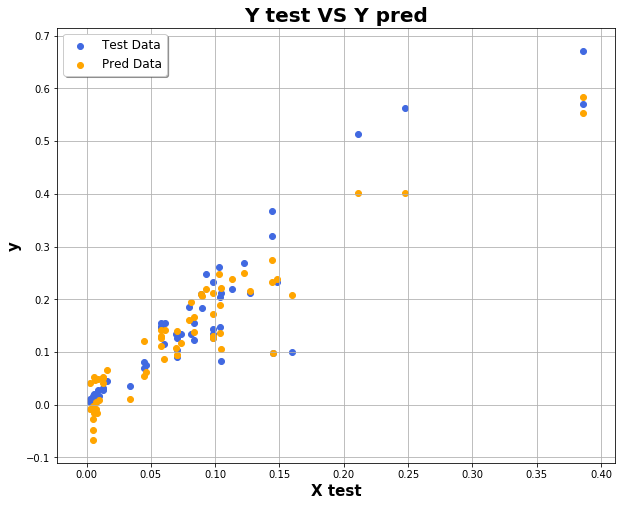

In [75]:
# plot data and compare y test VS y pred in Present_Price column
a = X_test['Present_Price']
b = y_test
c = X_test['Present_Price']
d = y_pred
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.scatter(c , d , c = 'orange' , label = 'Pred Data')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

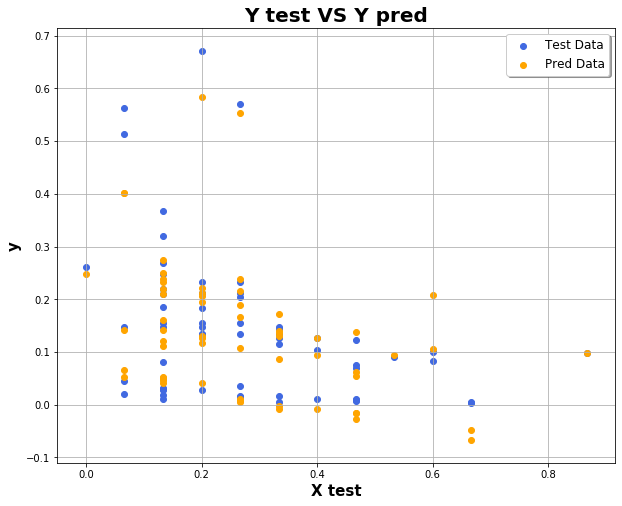

In [76]:
# plot data and compare y test VS y pred in Age column
a = X_test['Age']
b = y_test
c = X_test['Age']
d = y_pred
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.scatter(c , d , c = 'orange' , label = 'Pred Data')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

In [77]:
X_test.insert(8 , 'y_test' , y_test)            # add y_test and y_pred to dataframe for plot
X_test.insert(9 , 'y_pred' , y_pred)
X_test

,Age,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,y_test,y_pred
223,0.200000,0.800000,0.098396,0.121884,0.5,0.0,1.0,0.000000,0.233524,0.211426
150,0.466667,0.533333,0.005483,0.011011,1.0,1.0,1.0,0.000000,0.011461,-0.015381
226,0.200000,0.800000,0.058301,0.048404,1.0,0.0,1.0,0.000000,0.147564,0.127319
296,0.133333,0.866667,0.122237,0.067043,0.5,0.0,1.0,0.000000,0.269341,0.250732
52,0.066667,0.933333,0.210772,0.029029,0.5,0.0,0.0,0.000000,0.512894,0.401978
...,...,...,...,...,...,...,...,...,...,...
137,0.333333,0.666667,0.005061,0.031031,1.0,1.0,1.0,0.000000,0.015759,-0.002930
227,0.466667,0.533333,0.044538,0.113113,1.0,0.0,1.0,0.000000,0.070201,0.053589
26,0.333333,0.666667,0.060143,0.109385,1.0,0.0,1.0,0.000000,0.116046,0.086426
106,0.266667,0.733333,0.033919,0.032032,1.0,1.0,1.0,0.333333,0.035817,0.011597


In [78]:
df2 = X_test.sort_values(by=['Present_Price'])         # sort values for linear plot
df2

,Age,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,y_test,y_pred
166,0.133333,0.866667,0.002492,0.001001,1.0,1.0,1.0,0.000000,0.010029,0.041870
182,0.333333,0.666667,0.002818,0.059059,1.0,1.0,1.0,0.000000,0.005731,-0.007812
190,0.666667,0.333333,0.004660,0.119119,1.0,1.0,1.0,0.000000,0.002865,-0.047241
184,0.666667,0.333333,0.004660,0.051051,1.0,1.0,1.0,0.333333,0.004298,-0.067505
175,0.466667,0.533333,0.005061,0.149149,1.0,1.0,1.0,0.000000,0.008023,-0.027344
...,...,...,...,...,...,...,...,...,...,...
55,0.600000,0.400000,0.159515,0.139139,1.0,0.0,0.0,0.000000,0.100287,0.208008
52,0.066667,0.933333,0.210772,0.029029,0.5,0.0,0.0,0.000000,0.512894,0.401978
66,0.066667,0.933333,0.247399,0.021021,1.0,0.0,0.0,0.000000,0.563037,0.400879
59,0.266667,0.733333,0.386216,0.081081,0.5,0.0,0.0,0.000000,0.569914,0.554077


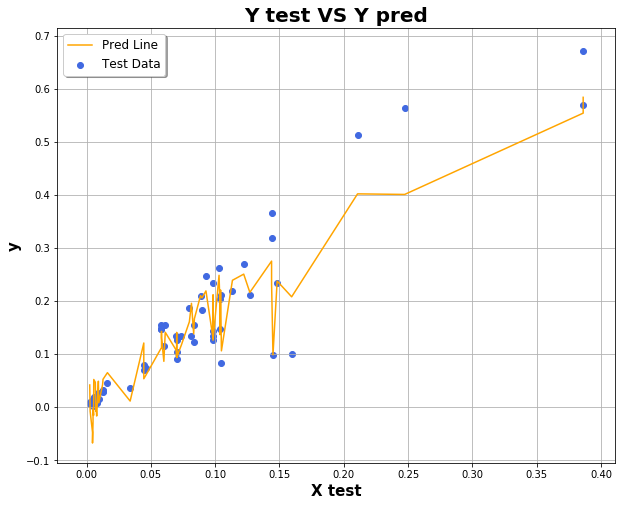

In [79]:
# plot data and compare y test VS y pred in Present_Price column
a = df2['Present_Price']
b = df2['y_test']
c = df2['Present_Price']
d = df2['y_pred']
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.plot(c , d , c = 'orange' , label = 'Pred Line')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

In [80]:
df3 = X_test.sort_values(by=['Age'])

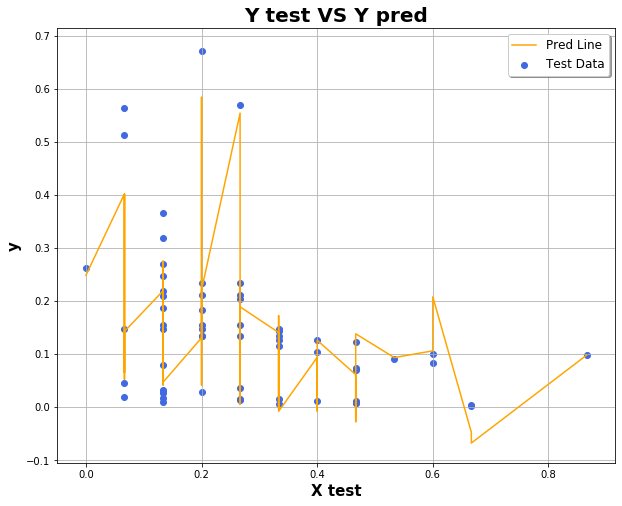

In [81]:
# plot data and compare y test VS y pred in Age column
a = df3['Age']
b = df3['y_test']
c = df3['Age']
d = df3['y_pred']
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.plot(c , d , c = 'orange' , label = 'Pred Line')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

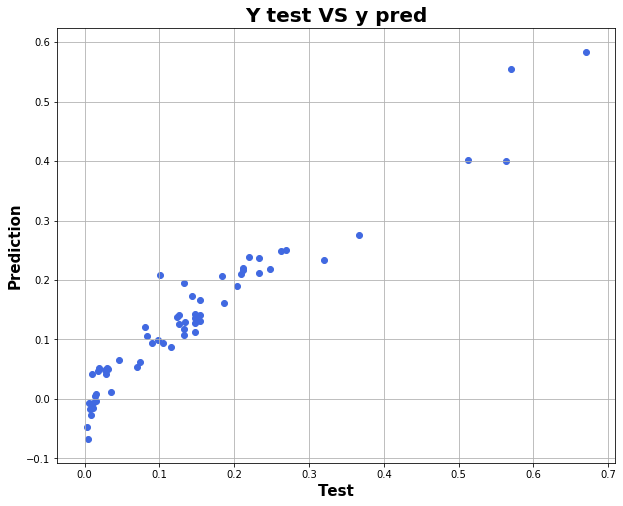

In [82]:
# compare y test VS y pred
plt.figure(figsize=(10 , 8))
plt.scatter(y_test , y_pred , c = 'royalblue')
plt.xlabel('Test' , fontsize=15 , fontweight ='bold')
plt.ylabel('Prediction' , fontsize=15 , fontweight ='bold')
plt.title('Y test VS y pred' , fontsize=20 , fontweight ='bold')
plt.grid()
plt.show()

In [83]:
print('MAE :' , metrics.mean_absolute_error(y_test , y_pred))     # Mean Absolute Error
print('MSE :' , metrics.mean_squared_error(y_test , y_pred))      # Mean Squared Error
print('RMSE :' , np.sqrt(metrics.mean_squared_error(y_test , y_pred)))    # Root Mean Squared Error
print('R2 Score :' , metrics.r2_score(y_test , y_pred))          # R2 Score

MAE : 0.028865279696233977
MSE : 0.001746855625023317
RMSE : 0.04179540196030321
R2 Score : 0.9158262133731003


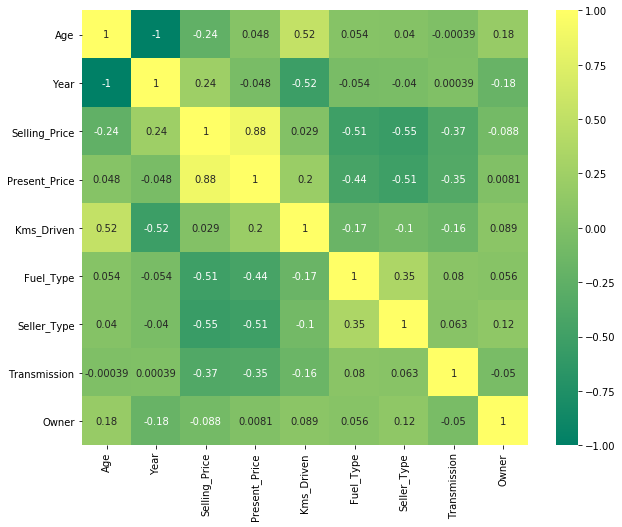

In [84]:
plt.figure(figsize=(10 , 8))                       
sns.heatmap(df.corr(),annot=True,cmap='summer')             # heatmap of correlations
plt.show()

In [85]:
## از هیت مپ ضرایب وابستگی مشخص است که تارگت قیمت بیشترین وابستگی را با قیمت فروش سابق و 
## نوع سوخت و نوع معامله دارد پس همگام افزودن جمله های اضافی به دیتافریم باید این اولویت را در نظر داشت 
## با توجه به اینکه اضافه کردن جمله به ستون های دسته بندی شده باینری بین ۰ و ۱ تغییری در جمله ایجاد نمیکند 
## از ستون های قیمت فروش سابق و سن و مسافت طی شده برای اضافه کردن جمله استفاده میکنیم

In [86]:
Scaler2 = preprocessing.MinMaxScaler(feature_range=(0 , 1))   #  Transform features by scaling each feature to a given range
norm2 = Scaler2.fit_transform(df)
norm_df2 = pd.DataFrame(norm2 , columns=['Age', 'Year', 'Selling_Price', 'Present_Price'
       , 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'])
norm_df2

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.733333,0.093123,0.057109,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.666667,0.133238,0.099913,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.933333,0.204871,0.103273,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.533333,0.078797,0.041504,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.733333,0.128940,0.070980,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
296,0.133333,0.866667,0.269341,0.122237,0.067043,0.5,0.0,1.0,0.0
297,0.200000,0.800000,0.111748,0.060468,0.119119,1.0,0.0,1.0,0.0
298,0.600000,0.400000,0.093123,0.115735,0.175043,1.0,0.0,1.0,0.0
299,0.066667,0.933333,0.326648,0.131990,0.017017,0.5,0.0,1.0,0.0


In [87]:
X = pd.DataFrame(norm_df2 , columns=['Age'  , 'Present_Price' ,
                                    'Kms_Driven' ,
                                    'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'])     # Selecting Features
y = norm_df2['Selling_Price'].values.reshape(-1 , 1)
X

,Age,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.057109,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.099913,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.103273,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.041504,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.070980,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...
296,0.133333,0.122237,0.067043,0.5,0.0,1.0,0.0
297,0.200000,0.060468,0.119119,1.0,0.0,1.0,0.0
298,0.600000,0.115735,0.175043,1.0,0.0,1.0,0.0
299,0.066667,0.131990,0.017017,0.5,0.0,1.0,0.0


In [88]:
Age2 = X['Age'] ** 3
X.insert(1 , 'Age2' , Age2)       # add new feature age as age2

In [89]:
Kms_Driven2 = X['Kms_Driven'] ** 3
X.insert(6 , 'Kms_Driven2' , Kms_Driven2)        # add new feature Kms_Driven as Kms_Driven2

In [90]:
Present_Price2 = X['Present_Price'] ** 3
X.insert(5 , 'Present_Price2' , Present_Price2)        # add new feature Present_Price as Present_Price2

In [91]:
## بعد از بررسی های فراوان و آزمون و خطاهای زیاد این فیچرها با توان ۳ طوری انتخاب شدند که به بیشترین دقت برسیم 
## در صورت استفاده از جملات بیشتر دقت مدلسازی پایین میاید

In [92]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.1 , random_state=0)
# Split arrays or matrices into random train and test subsets

In [93]:
new_model = LinearRegression()    # Creat a Regression Model for validate data

In [94]:
kfold_validation = KFold(10 , shuffle=True , random_state=0)

In [95]:
result = cross_val_score(new_model , X , y , cv=kfold_validation)

In [96]:
print(result)
print(np.mean(result))                # Fold 6 and 8 have negative values, which we will examine in the following

[ 0.89791629  0.95216     0.83176797  0.79405216  0.87626013 -6.22862583
  0.70674573 -5.45713225  0.88985402  0.89389489]
-0.4843106891881942


In [97]:
for train , test in kfold_validation.split(X):           # show the 10 fold with index
    print('test: %s' % (test))
    print('============================================================================================================')

test: [ 12  15  22  52  55  66  89 101 129 133 136 150 152 166 175 176 190 201
 205 212 214 215 221 223 224 225 226 246 261 285 296]
test: [  5   7   8  26  34  45  59  63  81  92 106 108 111 118 122 137 144 182
 184 216 227 234 238 241 250 253 254 263 271 282]
test: [ 20  27  37  46  64  73  74  76  90  97 116 135 145 146 158 164 173 179
 209 218 230 239 240 260 273 286 287 294 295 300]
test: [ 18  33  44  54  60  71  83 103 124 126 134 154 156 157 160 161 167 191
 208 210 217 222 229 245 247 252 255 281 283 289]
test: [  3   4  13  16  21  24  29  30  40  56  61  67  75  77  96 107 109 110
 125 139 153 159 168 171 187 198 200 236 274 280]
test: [  2  10  14  19  41  50  51  58  62  80  86 104 123 130 155 181 188 189
 194 213 228 233 235 237 256 267 269 270 278 293]
test: [  0  36  43  48  49  69  85  93  94  95  98 112 113 114 138 141 149 162
 178 199 206 207 219 220 249 262 276 291 297 298]
test: [  6  11  23  35  68  78  82  84  91 100 102 119 121 131 140 142 143 148
 170 180 196 2

In [98]:
df1=df.iloc[[2,10,14,19,41,50,51,58,62,80,86,104,123,130,155,181,188,189
,194,213,228,233,235,237,256,267,269,270,278,293,6,11,23,35,68,78,82,84,91,100,102,119,121,131,140,142,143,148
,170,180,196,203,204,248,257,258,268,275,284,299]]
df1                                                         # now we make the new dataframe with values of fold 6 , 8

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
2,2,2017,7.25,9.850,6900,2,0,1,0
10,2,2017,2.85,3.600,2135,2,0,1,0
14,10,2009,2.25,7.210,77427,2,0,1,0
19,9,2010,2.65,7.980,41442,2,0,1,0
41,5,2014,2.55,3.980,46706,2,0,1,0
50,7,2012,14.90,30.610,104707,1,0,0,0
51,4,2015,23.00,30.610,40000,1,0,0,0
58,5,2014,4.10,6.800,39485,2,0,1,1
62,5,2014,18.75,35.960,78000,1,0,0,0
80,3,2016,14.73,14.890,23000,1,0,1,0


In [99]:
df2 = df.drop(df.index[[2,10,14,19,41,50,51,58,62,80,86,104,123,130,155,181,188,189
,194,213,228,233,235,237,256,267,269,270,278,293,6,11,23,35,68,78,82,84,91,100,102,119,121,131,140,142,143,148
,170,180,196,203,204,248,257,258,268,275,284,299]])
df2.reset_index(drop=True)                                  # also we creat new dataframe without values of fold 6 , 8

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5,2014,3.35,5.59,27000,2,0,1,0
1,6,2013,4.75,9.54,43000,1,0,1,0
2,8,2011,2.85,4.15,5200,2,0,1,0
3,5,2014,4.60,6.87,42450,1,0,1,0
4,1,2018,9.25,9.83,2071,1,0,1,0
...,...,...,...,...,...,...,...,...,...
236,4,2015,8.55,13.09,60076,1,0,1,0
237,3,2016,9.50,11.60,33988,1,0,1,0
238,4,2015,4.00,5.90,60000,2,0,1,0
239,10,2009,3.35,11.00,87934,2,0,1,0


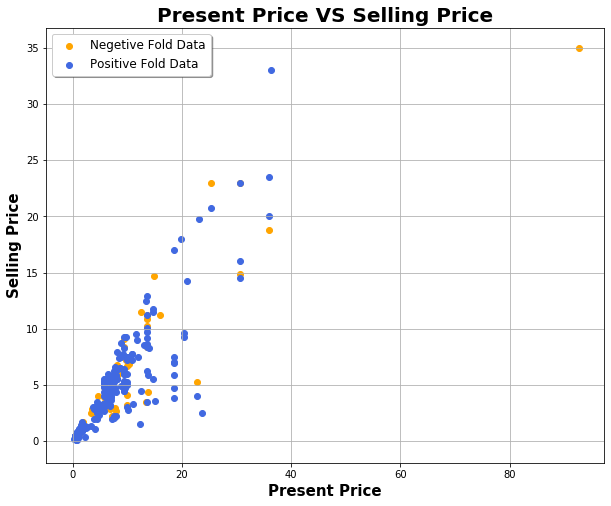

In [100]:
plt.figure(figsize=(10 , 8))
plt.scatter(df1['Present_Price'] , df1['Selling_Price'] , color='orange' , label='Negetive Fold Data')
plt.scatter(df2['Present_Price'] , df2['Selling_Price'] , color='royalblue' , label = 'Positive Fold Data')
plt.xlabel('Present Price' , fontsize=15 , fontweight ='bold')
plt.ylabel('Selling Price' , fontsize=15 , fontweight ='bold')
plt.title('Present Price VS Selling Price', fontsize=20 , fontweight ='bold')
plt.legend(shadow=True , fontsize=12)
plt.grid()
plt.show()

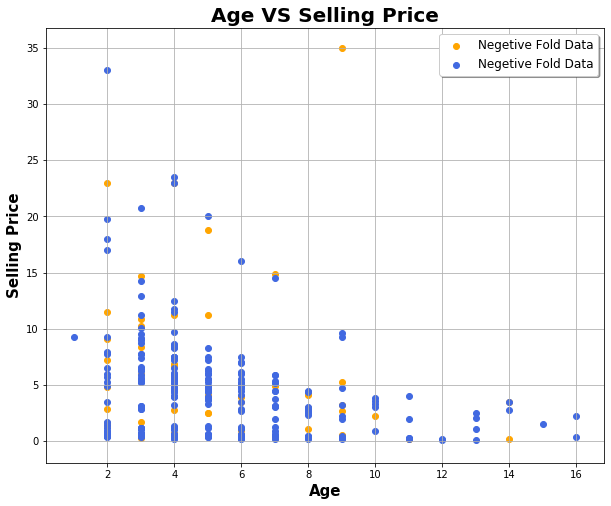

In [101]:
plt.figure(figsize=(10 , 8))
plt.scatter(df1['Age'] , df1['Selling_Price'] , color='orange' , label='Negetive Fold Data')
plt.scatter(df2['Age'] , df2['Selling_Price'] , color='royalblue' , label = 'Negetive Fold Data')
plt.xlabel('Age' , fontsize=15 , fontweight ='bold')
plt.ylabel('Selling Price' , fontsize=15 , fontweight ='bold')
plt.title('Age VS Selling Price', fontsize=20 , fontweight ='bold')
plt.legend(shadow=True , fontsize=12)
plt.grid()
plt.show()

In [102]:
##با توجه به توزیع مناسب دیتاهای با فولد منفی در کنار دیتاهای با فولد مثبت به غیر از دیتای مهم شماره ۸۶ 
## احتمال میدهیم که این دیتا باعث ناهماهنگی در خراب شدن دیتاها شده باشد پس ابتدا این سمپل را حذف کرده
## تا بتوانیم دوباره فولد بندی کنیم و سپس دوباره این سمپل را به خاطر اهمیت آن در مدلسازی به دیتا فریم اضافه میکنیم

In [103]:
df[df['Present_Price'] > 80]

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
86,9,2010,35.0,92.6,78000,1,0,1,0


In [104]:
new_df = df[df['Present_Price'] < 80]

In [105]:
Scaler3 = preprocessing.MinMaxScaler(feature_range=(0 , 1))   #  Transform features by scaling each feature to a given range
norm3 = Scaler3.fit_transform(new_df)
norm_df3 = pd.DataFrame(norm3 , columns=['Age', 'Year', 'Selling_Price', 'Present_Price'
       , 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'])
norm_df3

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.733333,0.098784,0.146756,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.666667,0.141337,0.256753,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.933333,0.217325,0.265386,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.533333,0.083587,0.106656,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.733333,0.136778,0.182400,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
295,0.133333,0.866667,0.285714,0.314119,0.067043,0.5,0.0,1.0,0.0
296,0.200000,0.800000,0.118541,0.155388,0.119119,1.0,0.0,1.0,0.0
297,0.600000,0.400000,0.098784,0.297410,0.175043,1.0,0.0,1.0,0.0
298,0.066667,0.933333,0.346505,0.339181,0.017017,0.5,0.0,1.0,0.0


In [106]:
X = pd.DataFrame(norm_df3 , columns=['Age' , 'Present_Price' ,
                                    'Kms_Driven',
                                    'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'])     # Selecting Features
y = norm_df3['Selling_Price'].values.reshape(-1 , 1)
X

,Age,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.146756,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.256753,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.265386,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.106656,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.182400,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...
295,0.133333,0.314119,0.067043,0.5,0.0,1.0,0.0
296,0.200000,0.155388,0.119119,1.0,0.0,1.0,0.0
297,0.600000,0.297410,0.175043,1.0,0.0,1.0,0.0
298,0.066667,0.339181,0.017017,0.5,0.0,1.0,0.0


In [107]:
Age2 = X['Age'] ** 3
X.insert(1 , 'Age2' , Age2)

In [108]:
Kms_Driven2 = X['Kms_Driven'] ** 3
X.insert(6 , 'Kms_Driven2' , Kms_Driven2)

In [109]:
Present_Price2 = X['Present_Price'] ** 3
X.insert(5 , 'Present_Price2' , Present_Price2)

In [110]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.1 , random_state=0)
# Split arrays or matrices into random train and test subsets

In [111]:
model_new2 = LinearRegression()

In [112]:
kfold_validation = KFold(10 , shuffle=True , random_state=0)

In [113]:
result = cross_val_score(model_new2 , X , y , cv=kfold_validation)

In [114]:
print(result)
print(np.mean(result))             # score of fold 10 is negeteve so we delete values of this fold

[ 0.88826243  0.90316215  0.93031826  0.80415024  0.86582027  0.91110578
  0.69047474  0.82964626  0.90221681 -6.72687837]
0.09982785798137259


In [115]:
for train, test in kfold_validation.split(X):
    print('test: %s' % (test))
    print('============================================================================================================')

test: [ 12  15  22  52  74  90 103 108 116 124 129 136 164 184 188 190 194 206
 208 221 222 229 230 234 239 248 270 286 290 295]
test: [  5   7   8  26  34  45  55  59  64  66  73  81  89  92 106 122 139 150
 153 168 173 176 182 213 219 223 236 253 284 299]
test: [ 20  27  37  46  63  76  97 111 118 134 135 144 145 156 160 191 212 214
 224 225 228 237 238 252 255 259 264 273 285 293]
test: [ 18  21  33  44  54  60  71  83 101 110 126 152 154 158 159 167 171 181
 189 205 215 227 245 249 250 272 280 281 282 288]
test: [  3   4  13  16  24  29  30  40  56  61  67  75  77  96 107 109 125 137
 146 157 161 166 175 198 201 220 262 268 279 291]
test: [  2  10  14  19  41  43  50  51  58  62  80  86 104 123 130 155 179 187
 199 200 209 210 226 233 235 241 254 260 266 292]
test: [  0  23  36  48  49  69  85  93  94  95  98 112 113 114 138 141 149 162
 178 207 216 217 218 240 247 261 275 294 296 297]
test: [  6  11  35  57  68  78  82  84  91 100 102 119 121 131 140 142 143 148
 170 180 196 203 2

In [116]:
df1 = df.drop(df.index[[9,25,39,47,70,72,87,88,99,115,117,147,165,172,174,177,192,193,195,197,
                  211,242,243,251,265,271,276,277,287,289]])
df1.reset_index(drop=True , inplace=True)                                                             

#در اینجا بخاطر این است که این دیتافریم شامل سمپل ۸۶ new_df به جای df استفاده از
##  (که سابقا برای فولد بندی آن را حذف کرده بودیم )

In [117]:
Scaler4 = preprocessing.MinMaxScaler(feature_range=(0 , 1))   #  Transform features by scaling each feature to a given range
norm4 = Scaler4.fit_transform(df1)
norm_df4 = pd.DataFrame(norm4 , columns=['Age', 'Year', 'Selling_Price', 'Present_Price'
       , 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'])
norm_df4

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.733333,0.093123,0.055574,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.666667,0.133238,0.098448,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.933333,0.204871,0.101813,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.533333,0.078797,0.039944,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.733333,0.128940,0.069467,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
266,0.133333,0.866667,0.269341,0.120808,0.067043,0.5,0.0,1.0,0.0
267,0.200000,0.800000,0.111748,0.058938,0.119119,1.0,0.0,1.0,0.0
268,0.600000,0.400000,0.093123,0.114295,0.175043,1.0,0.0,1.0,0.0
269,0.066667,0.933333,0.326648,0.130576,0.017017,0.5,0.0,1.0,0.0


In [118]:
X = pd.DataFrame(norm_df4 , columns=['Age' , 'Present_Price' ,
                                    'Kms_Driven',
                                    'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'])     # Selecting Features
y = norm_df4['Selling_Price'].values.reshape(-1 , 1)
X

,Age,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.055574,0.053053,1.0,0.0,1.0,0.0
1,0.333333,0.098448,0.085085,0.5,0.0,1.0,0.0
2,0.066667,0.101813,0.012813,1.0,0.0,1.0,0.0
3,0.466667,0.039944,0.009409,1.0,0.0,1.0,0.0
4,0.266667,0.069467,0.083984,0.5,0.0,1.0,0.0
...,...,...,...,...,...,...,...
266,0.133333,0.120808,0.067043,0.5,0.0,1.0,0.0
267,0.200000,0.058938,0.119119,1.0,0.0,1.0,0.0
268,0.600000,0.114295,0.175043,1.0,0.0,1.0,0.0
269,0.066667,0.130576,0.017017,0.5,0.0,1.0,0.0


In [119]:
Age2 = X['Age'] ** 3
X.insert(1 , 'Age2' , Age2)

In [120]:
Kms_Driven2 = X['Kms_Driven'] ** 3
X.insert(6 , 'Kms_Driven2' , Kms_Driven2)

In [121]:
Present_Price2 = X['Present_Price'] ** 3
X.insert(5 , 'Present_Price2' , Present_Price2)

In [122]:
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.1 , random_state=0)
# Split arrays or matrices into random train and test subsets

In [123]:
final_model2 = LinearRegression()          # final model

In [124]:
model.fit(X_train , y_train )

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [125]:
y_pred = model.predict(X_test)

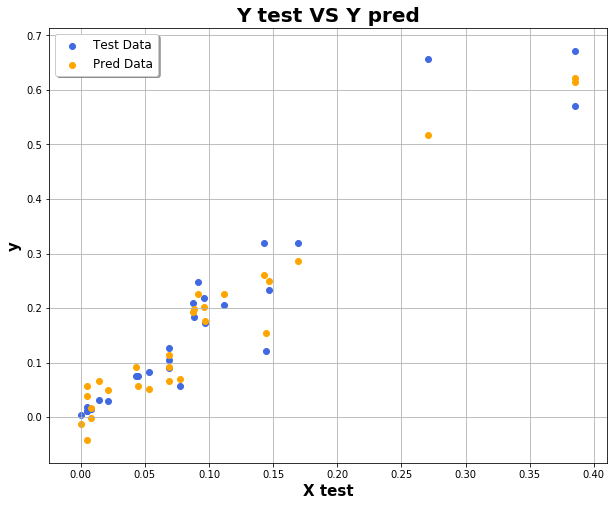

In [126]:
a = X_test['Present_Price']
b = y_test
c = X_test['Present_Price']
d = y_pred
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.scatter(c , d , c = 'orange' , label = 'Pred Data')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

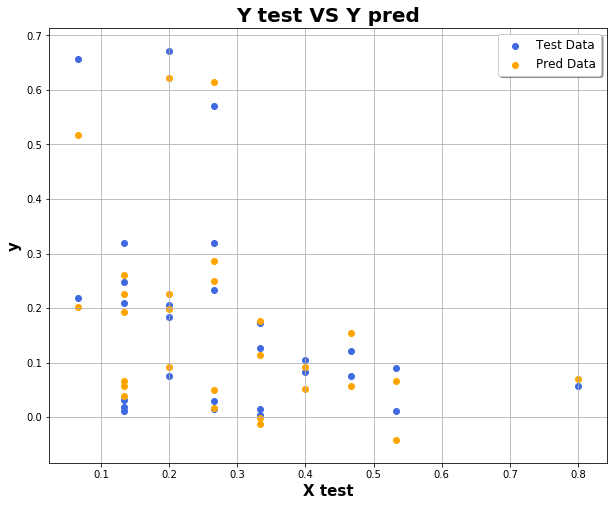

In [127]:
a = X_test['Age']
b = y_test
c = X_test['Age']
d = y_pred
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.scatter(c , d , c = 'orange' , label = 'Pred Data')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

In [128]:
X_test.insert(10 , 'y_test' , y_test)
X_test.insert(11 , 'y_pred' , y_pred)
X_test

,Age,Age2,Present_Price,Kms_Driven,Fuel_Type,Present_Price2,Seller_Type,Kms_Driven2,Transmission,Owner,y_test,y_pred
64,0.466667,0.101630,0.144036,0.175175,1.0,2.988199e-03,0.0,0.005375,1.0,0.000000,0.121777,0.154851
136,0.533333,0.151704,0.005101,0.089089,1.0,1.327671e-07,1.0,0.000707,1.0,0.000000,0.012034,-0.042367
223,0.400000,0.064000,0.068599,0.069069,1.0,3.228108e-04,0.0,0.000329,1.0,0.000000,0.104585,0.091154
129,0.333333,0.037037,0.007924,0.063063,1.0,4.974682e-07,1.0,0.000251,1.0,0.000000,0.014327,-0.001279
254,0.266667,0.018963,0.146858,0.125125,0.5,3.167307e-03,0.0,0.001959,1.0,0.000000,0.233524,0.249539
184,0.200000,0.008000,0.042983,0.055620,1.0,7.941131e-05,0.0,0.000172,1.0,0.000000,0.075931,0.091812
122,0.133333,0.002370,0.005210,0.000000,1.0,1.414231e-07,1.0,0.000000,1.0,0.000000,0.017765,0.057500
181,0.533333,0.151704,0.068599,0.115115,0.5,3.228108e-04,0.0,0.001525,1.0,0.333333,0.090258,0.066763
257,0.133333,0.002370,0.087159,0.029147,1.0,6.621302e-04,0.0,0.000025,0.0,0.000000,0.209169,0.192503
15,0.200000,0.008000,0.112016,0.082438,0.5,1.405516e-03,0.0,0.000560,1.0,0.000000,0.204871,0.226556


In [129]:
df2 = X_test.sort_values(by=['Present_Price'])
df2

,Age,Age2,Present_Price,Kms_Driven,Fuel_Type,Present_Price2,Seller_Type,Kms_Driven2,Transmission,Owner,y_test,y_pred
171,0.333333,0.037037,0.000434,0.063063,1.0,8.184210e-11,1.0,0.000251,1.0,0.000000,0.004298,-0.012724
137,0.133333,0.002370,0.005101,0.047047,1.0,1.327671e-07,1.0,0.000104,1.0,0.000000,0.011748,0.038044
136,0.533333,0.151704,0.005101,0.089089,1.0,1.327671e-07,1.0,0.000707,1.0,0.000000,0.012034,-0.042367
122,0.133333,0.002370,0.005210,0.000000,1.0,1.414231e-07,1.0,0.000000,1.0,0.000000,0.017765,0.057500
129,0.333333,0.037037,0.007924,0.063063,1.0,4.974682e-07,1.0,0.000251,1.0,0.000000,0.014327,-0.001279
125,0.266667,0.018963,0.007924,0.046046,1.0,4.974682e-07,1.0,0.000098,1.0,0.000000,0.015759,0.017137
101,0.133333,0.002370,0.014219,0.011011,1.0,2.874820e-06,1.0,0.000001,1.0,0.000000,0.031519,0.066741
103,0.266667,0.018963,0.020949,0.013013,1.0,9.193242e-06,1.0,0.000002,1.0,0.000000,0.030086,0.050573
184,0.200000,0.008000,0.042983,0.055620,1.0,7.941131e-05,0.0,0.000172,1.0,0.000000,0.075931,0.091812
204,0.466667,0.101630,0.044828,0.044078,1.0,9.008385e-05,0.0,0.000086,1.0,0.000000,0.074499,0.056268


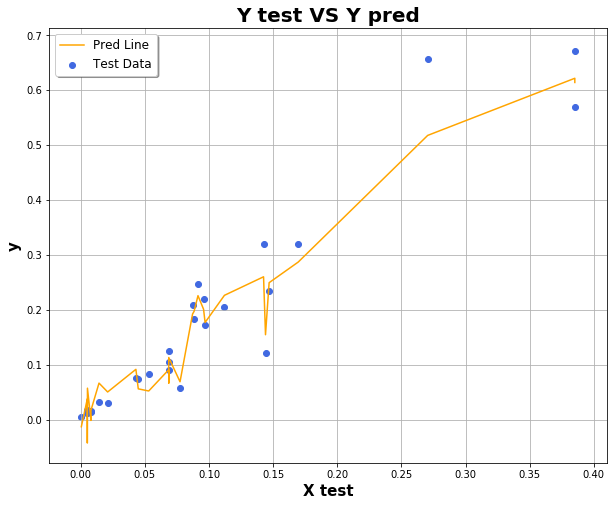

In [130]:
a = df2['Present_Price']
b = df2['y_test']
c = df2['Present_Price']
d = df2['y_pred']
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.plot(c , d , c = 'orange' , label = 'Pred Line')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

In [131]:
df3 = X_test.sort_values(by=['Age'])

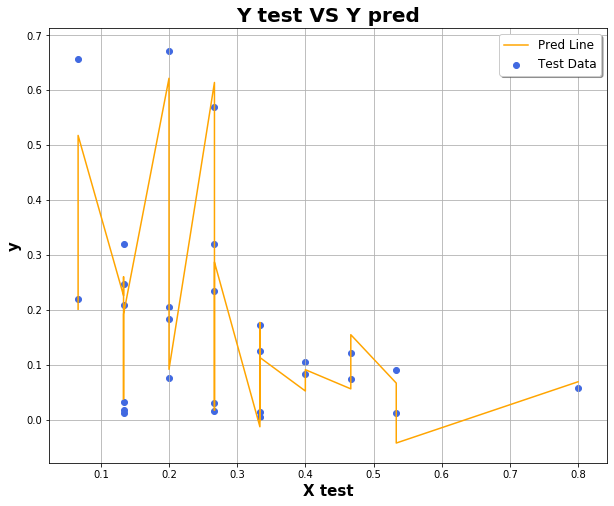

In [132]:
a = df3['Age']
b = df3['y_test']
c = df3['Age']
d = df3['y_pred']
plt.figure(figsize=(10 , 8))
plt.scatter(a , b , c = 'royalblue' , label = 'Test Data')
plt.plot(c , d , c = 'orange' , label = 'Pred Line')
plt.xlabel('X test' ,  fontsize=15 , fontweight ='bold')
plt.ylabel('y' ,  fontsize=15 , fontweight ='bold')
plt.title('Y test VS Y pred',  fontsize=20 , fontweight ='bold')
plt.legend(shadow = True , fontsize = 12)
plt.grid()

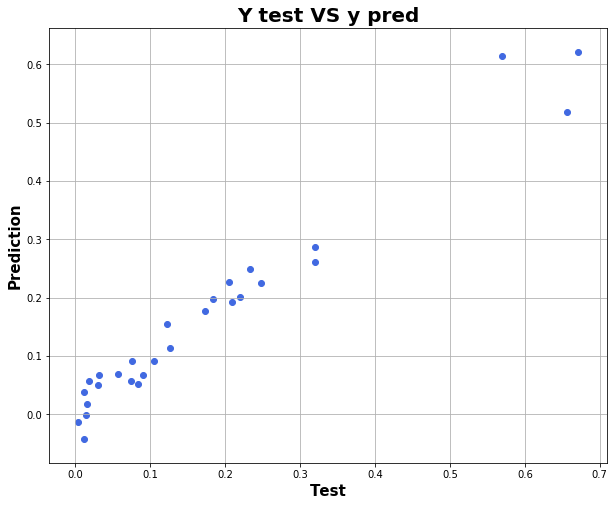

In [133]:
plt.figure(figsize=(10 , 8))
plt.scatter(y_test , y_pred , c = 'royalblue')
plt.xlabel('Test' , fontsize=15 , fontweight ='bold')
plt.ylabel('Prediction' , fontsize=15 , fontweight ='bold')
plt.title('Y test VS y pred' , fontsize=20 , fontweight ='bold')
plt.grid()
plt.show()

In [134]:
print('MAE :' , metrics.mean_absolute_error(y_test , y_pred))
print('MSE :' , metrics.mean_squared_error(y_test , y_pred))
print('RMSE :' , np.sqrt(metrics.mean_squared_error(y_test , y_pred)))
print('R2 Score :' , metrics.r2_score(y_test , y_pred))

MAE : 0.028736577242679664
MSE : 0.0014700824680635779
RMSE : 0.03834165447739023
R2 Score : 0.9565314046303188


## Predict New Data

In [135]:
df_pred = pd.Series({'Age':10 ,
                     'Year':2009,
                     'Selling_Price':4 ,
                        'Present_Price':11.23,
                        'Kms_Driven':42000,
                        'Fuel_Type':2 ,
                        'Seller_Type':0,
                        'Transmission':0,
                        'Owner': 1})

In [136]:
df3 = df1.append(df_pred , ignore_index=True)
df3

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5.0,2014.0,3.35,5.59,27000.0,2.0,0.0,1.0,0.0
1,6.0,2013.0,4.75,9.54,43000.0,1.0,0.0,1.0,0.0
2,2.0,2017.0,7.25,9.85,6900.0,2.0,0.0,1.0,0.0
3,8.0,2011.0,2.85,4.15,5200.0,2.0,0.0,1.0,0.0
4,5.0,2014.0,4.60,6.87,42450.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
267,4.0,2015.0,4.00,5.90,60000.0,2.0,0.0,1.0,0.0
268,10.0,2009.0,3.35,11.00,87934.0,2.0,0.0,1.0,0.0
269,2.0,2017.0,11.50,12.50,9000.0,1.0,0.0,1.0,0.0
270,3.0,2016.0,5.30,5.90,5464.0,2.0,0.0,1.0,0.0


In [137]:
Scaler5 = preprocessing.MinMaxScaler(feature_range=(0 , 1))   #  Transform features by scaling each feature to a given range
norm5 = Scaler5.fit_transform(df3)
norm_df5 = pd.DataFrame(norm5 , columns=['Age', 'Year', 'Selling_Price', 'Present_Price'
       , 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'])
norm_df5

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,0.266667,0.733333,0.093123,0.055574,0.053053,1.0,0.0,1.0,0.000000
1,0.333333,0.666667,0.133238,0.098448,0.085085,0.5,0.0,1.0,0.000000
2,0.066667,0.933333,0.204871,0.101813,0.012813,1.0,0.0,1.0,0.000000
3,0.466667,0.533333,0.078797,0.039944,0.009409,1.0,0.0,1.0,0.000000
4,0.266667,0.733333,0.128940,0.069467,0.083984,0.5,0.0,1.0,0.000000
...,...,...,...,...,...,...,...,...,...
267,0.200000,0.800000,0.111748,0.058938,0.119119,1.0,0.0,1.0,0.000000
268,0.600000,0.400000,0.093123,0.114295,0.175043,1.0,0.0,1.0,0.000000
269,0.066667,0.933333,0.326648,0.130576,0.017017,0.5,0.0,1.0,0.000000
270,0.133333,0.866667,0.148997,0.058938,0.009938,1.0,0.0,1.0,0.000000


In [138]:
Age2 = norm_df5['Age'] ** 3
norm_df5.insert(1 , 'Age2' , Age2)

In [139]:
Kms_Driven2 = norm_df5['Kms_Driven'] ** 3
norm_df5.insert(6 , 'Kms_Driven2' , Kms_Driven2)  

In [140]:
Present_Price2 = norm_df5['Present_Price'] ** 3
norm_df5.insert(5 , 'Present_Price2' , Present_Price2) 

In [141]:
X_train = norm_df5[['Age', 'Age2', 'Present_Price',
       'Present_Price2', 'Kms_Driven', 'Kms_Driven2', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner']][:271]

y_train = norm_df5[['Selling_Price']][:271].values.reshape(-1 , 1)

X_test =norm_df5[['Age', 'Age2', 'Present_Price',
       'Present_Price2', 'Kms_Driven', 'Kms_Driven2', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner']][271:]

In [142]:
final_model2.fit(X_train , y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [143]:
y_pred = final_model2.predict(X_test)

In [144]:
print(y_pred)

[[0.12195089]]


In [145]:
## مقدار پیش بینی شده را در جای قیمت فروش قرار میدهیم تا بعد از برگرداندن دیتافریم از حالت نرمالایز به حالت قبل به جواب برسیم

In [146]:
norm_df5.iloc[271]['Selling_Price']

0.11174785100286534

In [147]:
norm_df5['Selling_Price'].replace({0.11174785100286534 : 0.15782521} , inplace =True)

In [148]:
inverse_data = Scaler5.inverse_transform(norm_df5[['Age', 'Year', 'Selling_Price', 'Present_Price'
       , 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner']])

In [149]:
df_predict = pd.DataFrame(inverse_data , columns = ['Age', 'Year', 'Selling_Price', 'Present_Price'
       , 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner'])

In [150]:
df_predict

,Age,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,5.0,2014.0,3.3500,5.59,27000.0,2.0,0.0,1.0,0.0
1,6.0,2013.0,4.7500,9.54,43000.0,1.0,0.0,1.0,0.0
2,2.0,2017.0,7.2500,9.85,6900.0,2.0,0.0,1.0,0.0
3,8.0,2011.0,2.8500,4.15,5200.0,2.0,0.0,1.0,0.0
4,5.0,2014.0,4.6000,6.87,42450.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
267,4.0,2015.0,5.6081,5.90,60000.0,2.0,0.0,1.0,0.0
268,10.0,2009.0,3.3500,11.00,87934.0,2.0,0.0,1.0,0.0
269,2.0,2017.0,11.5000,12.50,9000.0,1.0,0.0,1.0,0.0
270,3.0,2016.0,5.3000,5.90,5464.0,2.0,0.0,1.0,0.0


In [151]:
print('Predict Price Of This Car is : ' , df_predict.iloc[271]['Selling_Price'])

Predict Price Of This Car is :  5.6080998289999995
